<a href="https://colab.research.google.com/github/springboardmentor891v/CreditPathAI/blob/Rajath/notebooks/pre_processing__methods_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pip install numpy==1.23.5

In [2]:
import pandas as pd
import numpy as np
import cufflinks as cf
import plotly.offline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
# Set up the connection to Plotly
cf.go_offline()

In [4]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Loan_Default.csv')

Mounted at /content/drive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [6]:
df.Status.unique()

array([1, 0])

In [7]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [8]:
df=df.drop(['ID','year', 'construction_type', 'Secured_by', 'Security_Type', 'open_credit'],axis=1)

In [9]:

from sklearn.model_selection import train_test_split

# Separate features (X) and target (y) before any processing
X = df.drop('Status', axis=1)
y = df['Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=39, stratify=y)

In [10]:
df.head(5)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,business_or_commercial,loan_amount,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nob/c,116500,...,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,b/c,206500,...,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nob/c,406500,...,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nob/c,456500,...,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nob/c,696500,...,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,0,39.0


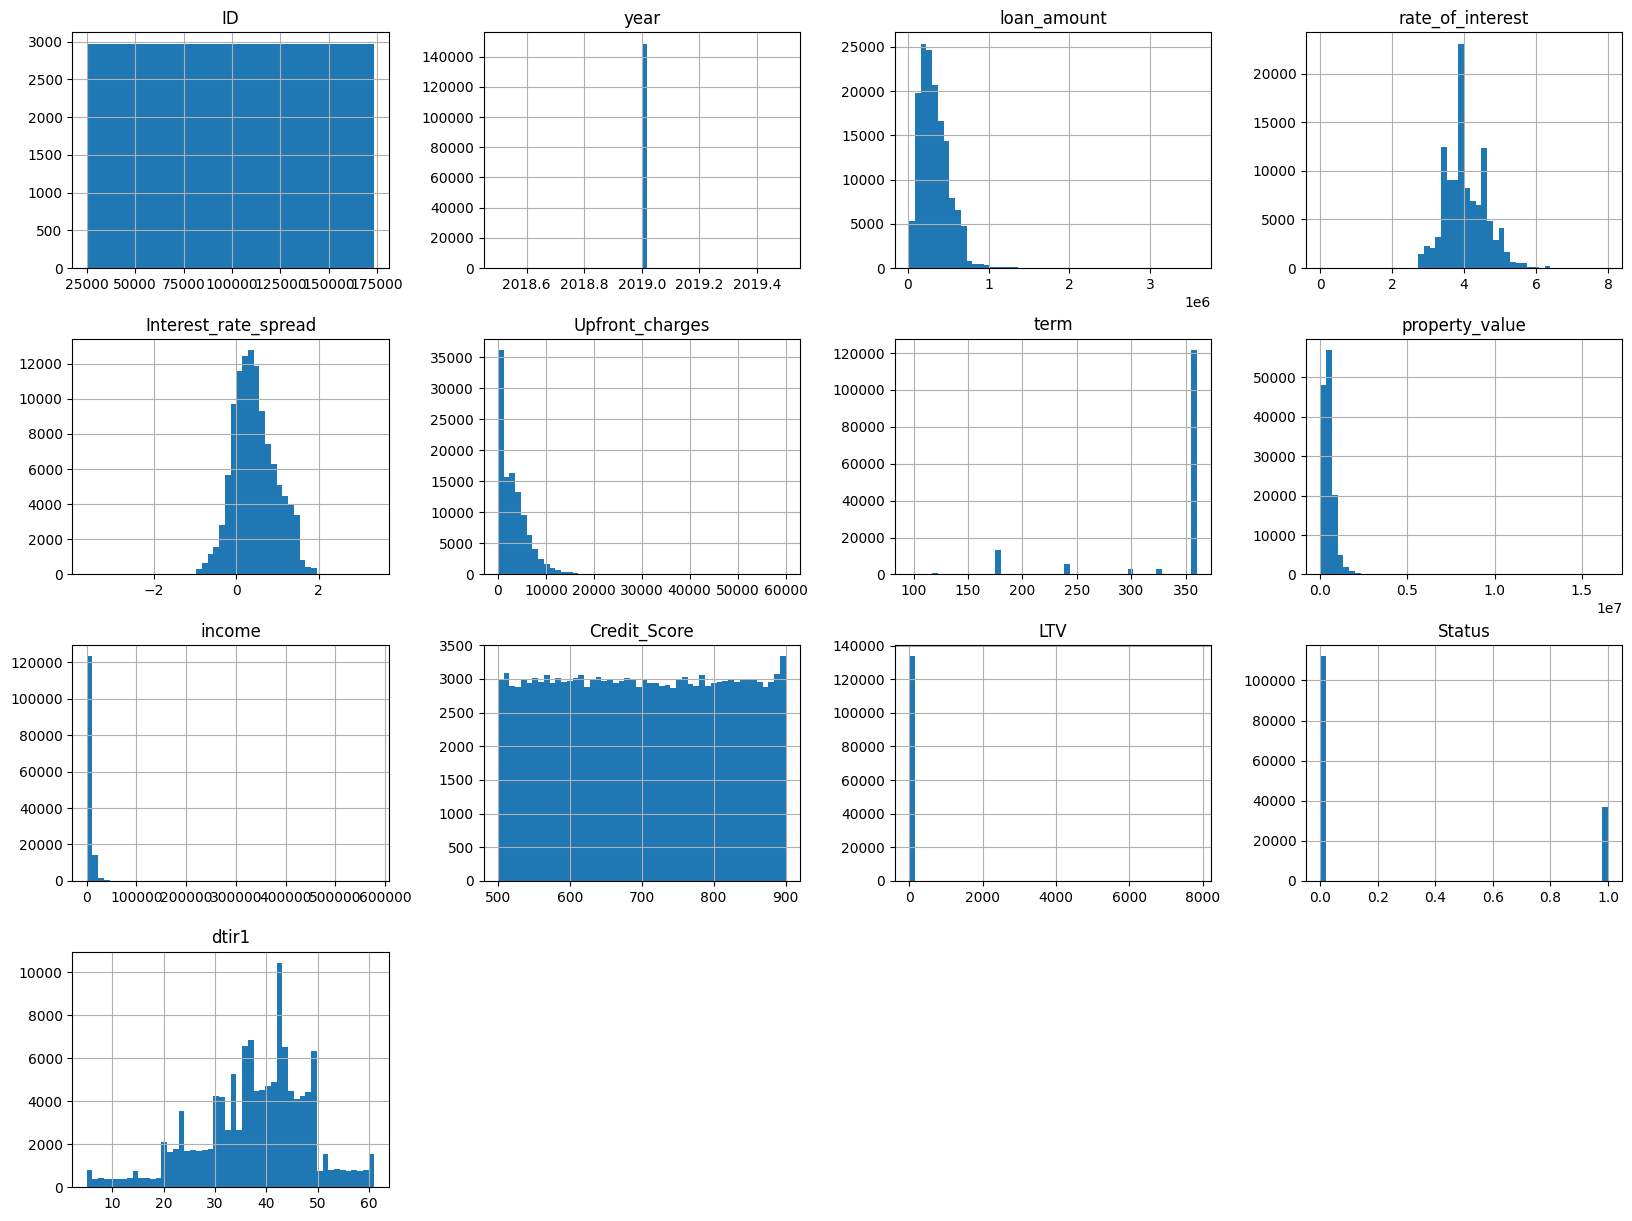

In [11]:
# Numerical data histogram to show the distribution  balance of data and ranges
df.hist(bins = 50, figsize = (20, 15))
plt.show()

In [12]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
business_or_commercial,0
loan_amount,0


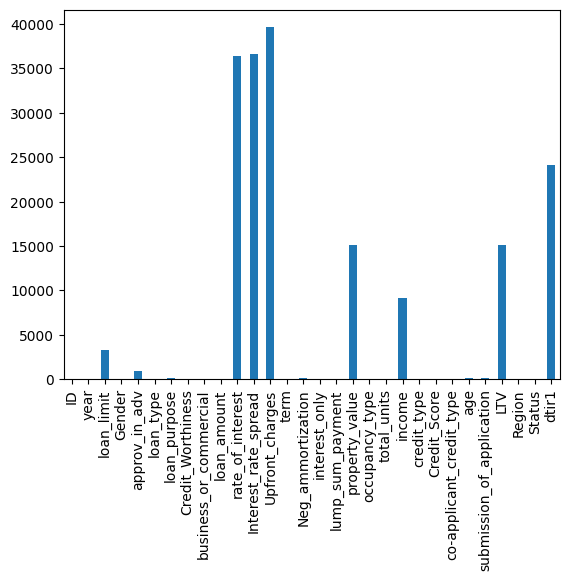

In [13]:
df.isna().sum().plot.bar()
plt.show()

null values in some features scores apploxematly 27%(the maximum ) of total data

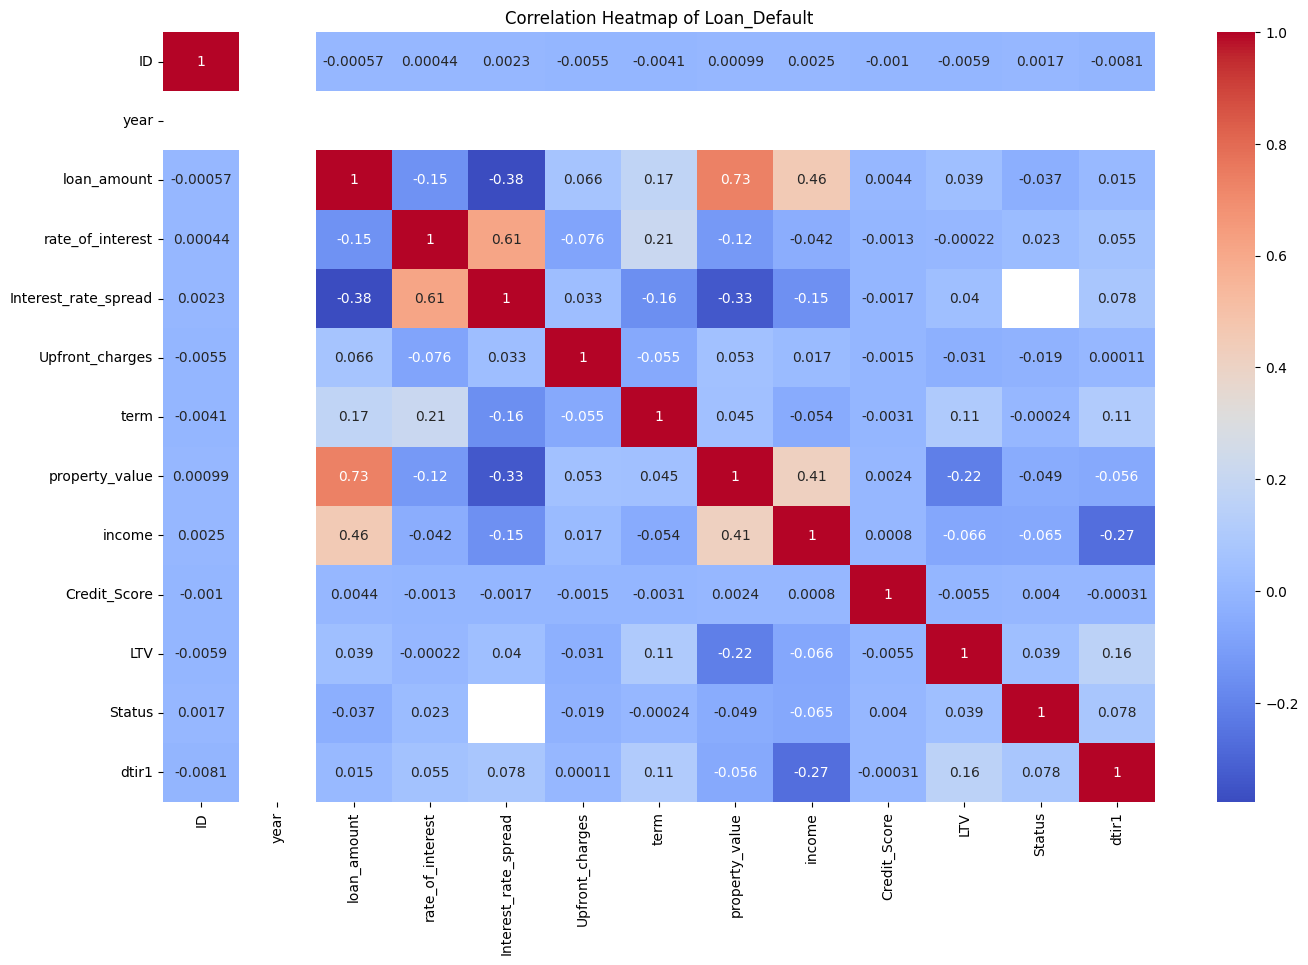

In [14]:
#heat map for the numerical columns

numerical_cols = df.select_dtypes(include=['number'])

correlation_matrix = numerical_cols.corr()


plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Loan_Default')
plt.show()

In [15]:


# --- DEFINE COLUMN TYPES FROM THE TRAINING SET ---
# This ensures we are only working with feature columns

num=[]
for x in X_train.columns:
    if X_train[x].dtype == 'int64' or X_train[x].dtype == 'float64':
        num.append(x)

print("Numerical columns identified:", num)

cat=[]
for x in X_train.columns:
    if X_train[x].dtype == 'object':
        cat.append(x)

print("Categorical columns identified:", cat)

Numerical columns identified: ['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']
Categorical columns identified: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'occupancy_type', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region']


In [16]:
'''columns_to_check = [
    'open_credit', 'loan_limit', 'approv_in_adv', 'credit_worthiness',
    'business_or_commercial', 'neg_ammortization', 'interest_only',
    'lump_sum_payment', 'construction_type', 'secured_by',
    'submission_of_application', 'security_type'
]

for col in columns_to_check:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("\n" + "="*30 + "\n")'''

'columns_to_check = [\n    \'open_credit\', \'loan_limit\', \'approv_in_adv\', \'credit_worthiness\',\n    \'business_or_commercial\', \'neg_ammortization\', \'interest_only\',\n    \'lump_sum_payment\', \'construction_type\', \'secured_by\',\n    \'submission_of_application\', \'security_type\'\n]\n\nfor col in columns_to_check:\n    print(f"Value counts for \'{col}\':")\n    print(df[col].value_counts())\n    print("\n" + "="*30 + "\n")'

:the most needed loan is is from type1 and thethe amount nearly(200k to 400k)


In [17]:
#null values numerical
for i in df.columns:
    print(i ,":" ,df[i].unique())

ID : [ 24890  24891  24892 ... 173557 173558 173559]
year : [2019]
loan_limit : ['cf' nan 'ncf']
Gender : ['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv : ['nopre' 'pre' nan]
loan_type : ['type1' 'type2' 'type3']
loan_purpose : ['p1' 'p4' 'p3' 'p2' nan]
Credit_Worthiness : ['l1' 'l2']
business_or_commercial : ['nob/c' 'b/c']
loan_amount : [ 116500  206500  406500  456500  696500  706500  346500  266500  376500
  436500  136500  466500  226500   76500  356500  156500  586500  306500
  316500  336500  426500  476500  196500  186500  246500  216500  506500
  656500  256500  396500  166500  236500  866500  416500  386500  596500
  606500   86500  286500  146500  446500  636500  486500  326500   56500
  906500  496500  106500  126500  296500  176500 1376500  566500  686500
  556500  676500  366500  276500  716500   66500  616500   96500  826500
   26500  666500  546500  986500  526500 1226500  726500 1486500 1416500
  536500  796500  516500   46500  876500  576500  626500 15065

In [18]:



from sklearn.impute import SimpleImputer

# Impute numerical columns: FIT on train, TRANSFORM on both
median_imputer = SimpleImputer(strategy='median')
X_train[num] = median_imputer.fit_transform(X_train[num])
X_test[num] = median_imputer.transform(X_test[num])

# Impute categorical columns: FIT on train, TRANSFORM on both
for col in cat:
    mode_val = X_train[col].mode()[0]
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

/tmp/ipython-input-3373525199.py:11: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-3373525199.py:12: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [19]:
df[cat].isnull().sum()

,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
business_or_commercial,0
Neg_ammortization,121
interest_only,0
lump_sum_payment,0


In [20]:
df[num].isnull().sum()

,0
ID,0
year,0
loan_amount,0
rate_of_interest,36439
Interest_rate_spread,36639
Upfront_charges,39642
term,41
property_value,15098
income,9150
Credit_Score,0


,0
ID,"Axes(0.125,0.747241;0.227941x0.132759)"
year,"Axes(0.398529,0.747241;0.227941x0.132759)"
loan_amount,"Axes(0.672059,0.747241;0.227941x0.132759)"
rate_of_interest,"Axes(0.125,0.587931;0.227941x0.132759)"
Interest_rate_spread,"Axes(0.398529,0.587931;0.227941x0.132759)"
Upfront_charges,"Axes(0.672059,0.587931;0.227941x0.132759)"
term,"Axes(0.125,0.428621;0.227941x0.132759)"
property_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
income,"Axes(0.672059,0.428621;0.227941x0.132759)"
Credit_Score,"Axes(0.125,0.26931;0.227941x0.132759)"


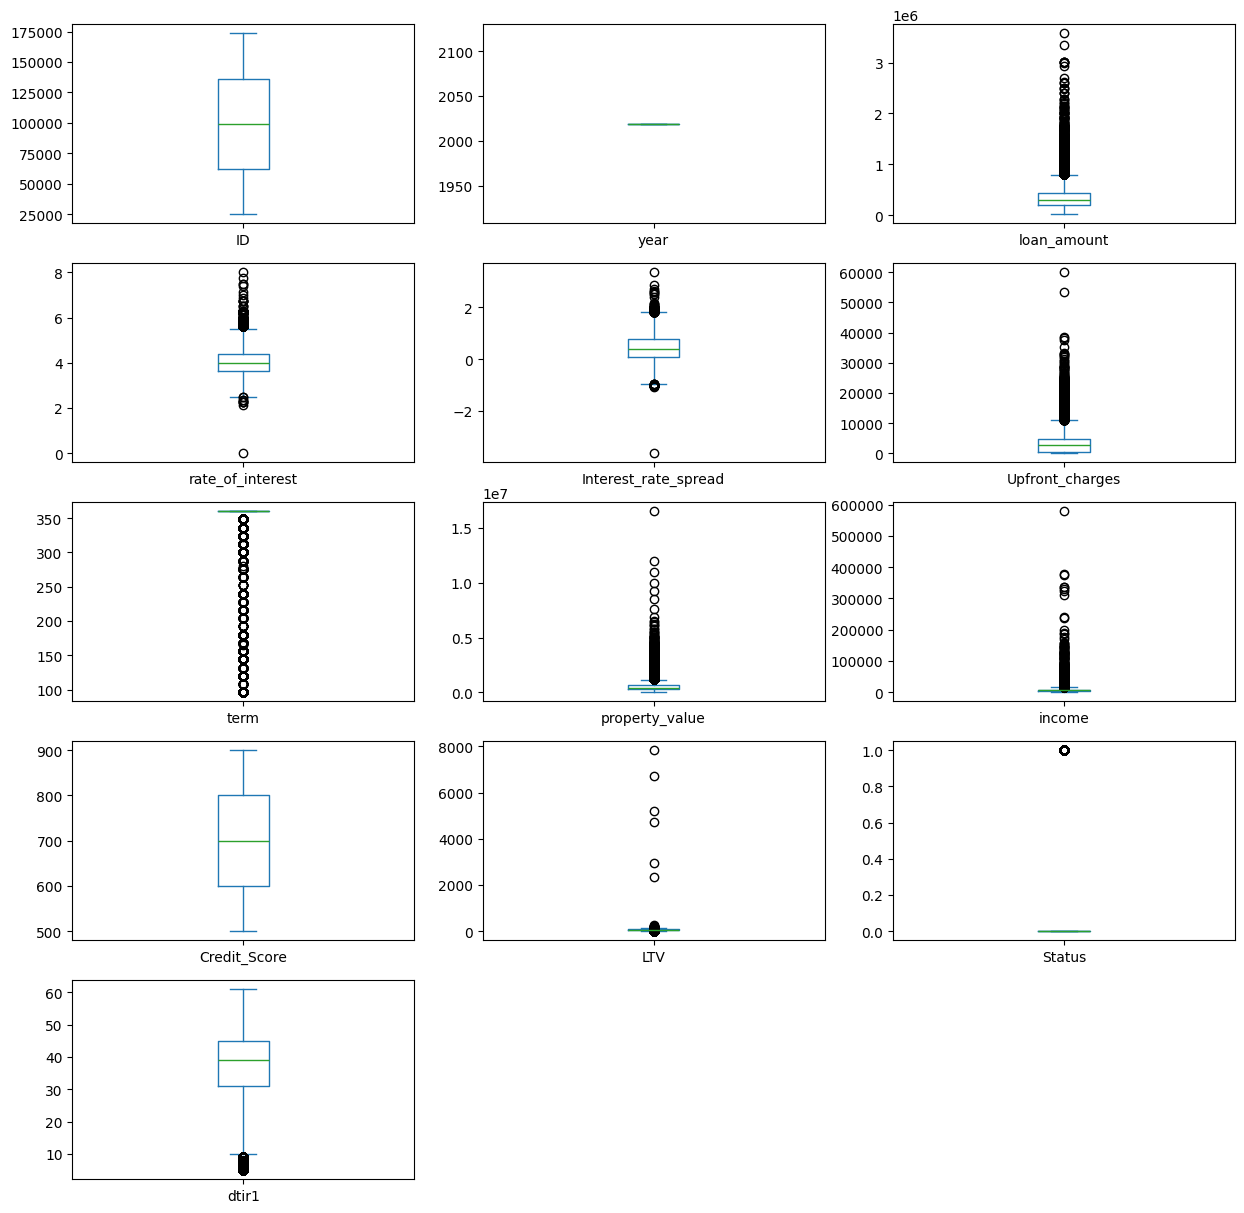

In [21]:
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,15))

## all others except credit_score has overliers

In [22]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
business_or_commercial,0
loan_amount,0


In [23]:

# Calculate IQR bounds from the TRAINING data only
Q1 = X_train[num].quantile(0.25)
Q3 = X_train[num].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in the training set
train_outliers_mask = ~((X_train[num] < lower_bound) | (X_train[num] > upper_bound)).any(axis=1)

# Remove outliers from both X_train and y_train
X_train = X_train[train_outliers_mask]
y_train = y_train[train_outliers_mask]

# Identify and remove outliers from the test set using the SAME bounds
test_outliers_mask = ~((X_test[num] < lower_bound) | (X_test[num] > upper_bound)).any(axis=1)
X_test = X_test[test_outliers_mask]
y_test = y_test[test_outliers_mask]

,0
ID,"Axes(0.125,0.747241;0.227941x0.132759)"
year,"Axes(0.398529,0.747241;0.227941x0.132759)"
loan_amount,"Axes(0.672059,0.747241;0.227941x0.132759)"
rate_of_interest,"Axes(0.125,0.587931;0.227941x0.132759)"
Interest_rate_spread,"Axes(0.398529,0.587931;0.227941x0.132759)"
Upfront_charges,"Axes(0.672059,0.587931;0.227941x0.132759)"
term,"Axes(0.125,0.428621;0.227941x0.132759)"
property_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
income,"Axes(0.672059,0.428621;0.227941x0.132759)"
Credit_Score,"Axes(0.125,0.26931;0.227941x0.132759)"


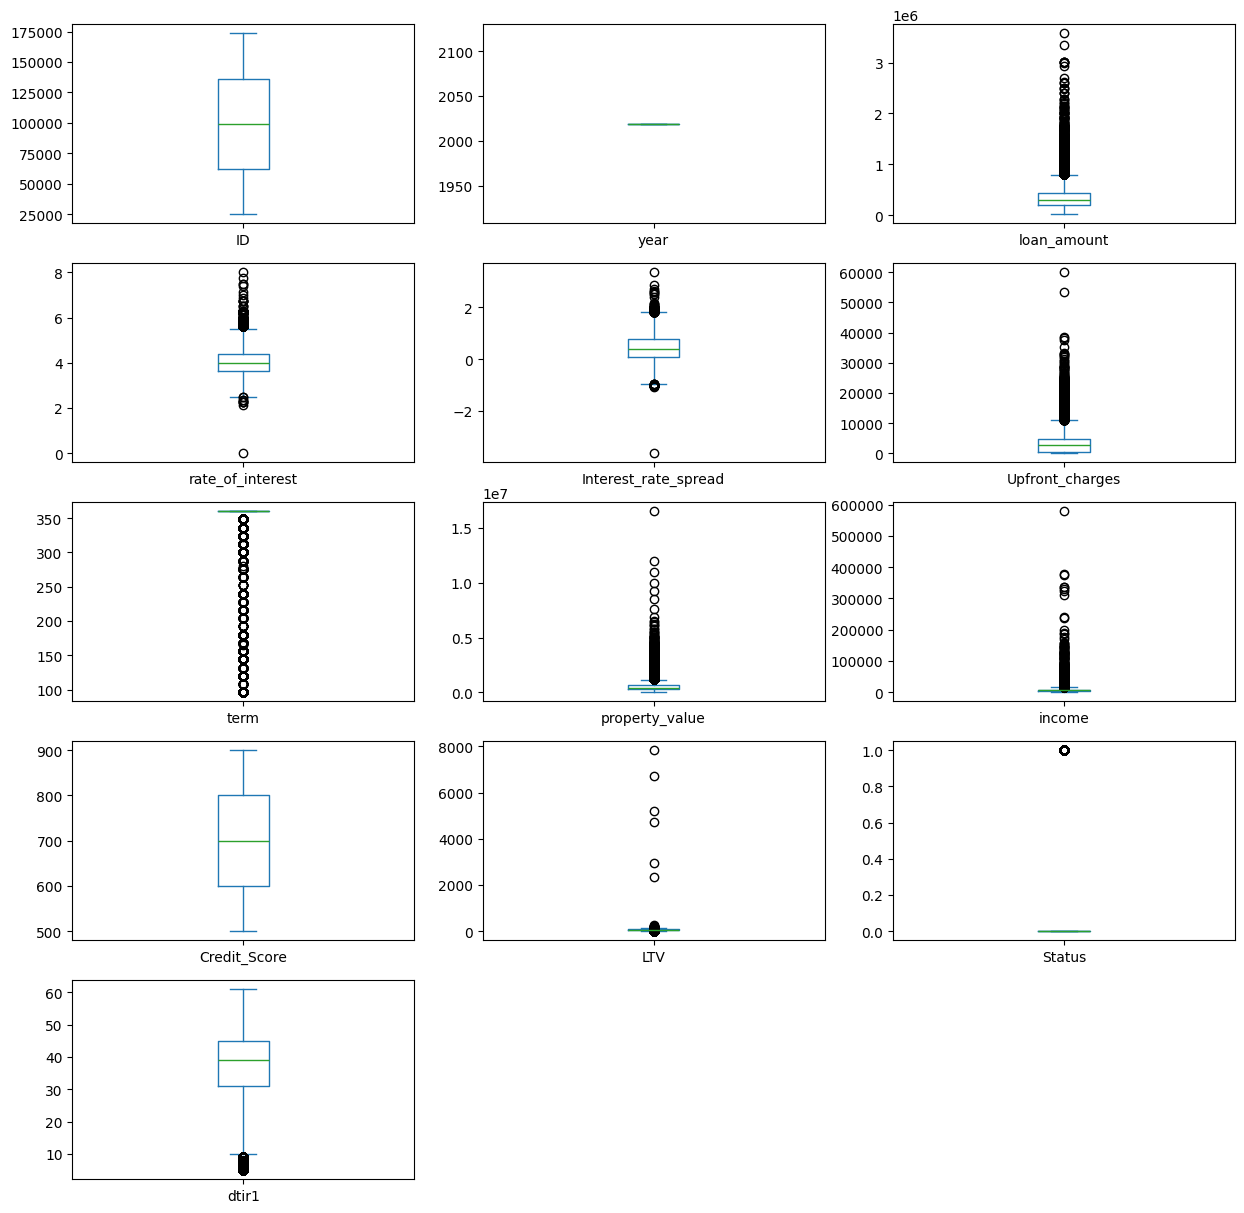

In [24]:
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,15))

In [25]:
df.Status.unique()

array([1, 0])

In [26]:

from sklearn.preprocessing import LabelEncoder


X_train = X_train.copy()
X_test = X_test.copy()

for i in cat:
    label = LabelEncoder()

    X_train[i] = label.fit_transform(X_train[i])
    X_test[i] = label.transform(X_test[i])

In [27]:
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,business_or_commercial,loan_amount,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nob/c,116500,...,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,b/c,206500,...,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nob/c,406500,...,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nob/c,456500,...,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nob/c,696500,...,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nob/c,436500,...,7860.0,CIB,659,EXP,55-64,to_inst,71.792763,south,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nob/c,586500,...,7140.0,CIB,569,CIB,25-34,not_inst,74.428934,south,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nob/c,446500,...,6900.0,CIB,702,EXP,45-54,not_inst,61.332418,North,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nob/c,196500,...,7140.0,EXP,737,EXP,55-64,to_inst,70.683453,North,0,29.0


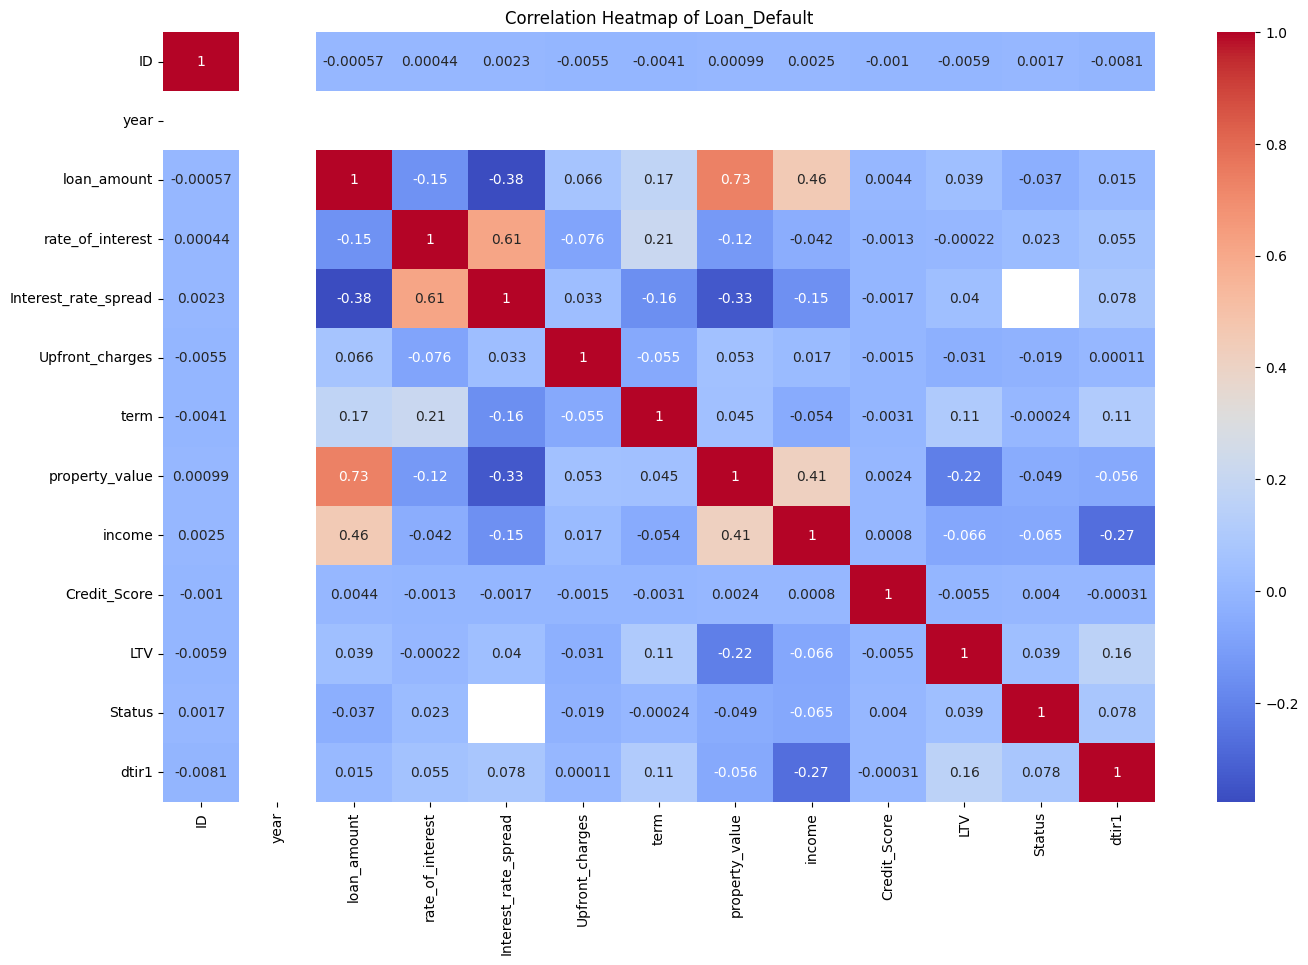

In [28]:
# heatmap for all features after encoding categorical data
numerical_cols = df.select_dtypes(include=['number'])


correlation_matrix = numerical_cols.corr()


plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Loan_Default')
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   business_or_commercial     148670 non-null  object 
 9   loan_amount                148670 non-null  int64  
 10  rate_of_interest           112231 non-null  float64
 11  Interest_rate_spread       112031 non-null  float64
 12  Upfront_charges            109028 non-null  float64
 13  term                       14

In [30]:

column_names = df.columns
print(column_names)


Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'occupancy_type', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Status', 'dtir1'],
      dtype='object')


In [31]:
# --- 2. ADD THIS VERIFICATION STEP ---
# Check the data types. There should be NO 'object' types left.
print("Data types in X_train before scaling:")
print(X_train.dtypes)

Data types in X_train before scaling:
ID                           float64
year                         float64
loan_limit                     int64
Gender                         int64
approv_in_adv                  int64
loan_type                      int64
loan_purpose                   int64
Credit_Worthiness              int64
business_or_commercial         int64
loan_amount                  float64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization              int64
interest_only                  int64
lump_sum_payment               int64
property_value               float64
occupancy_type                 int64
total_units                    int64
income                       float64
credit_type                    int64
Credit_Score                 float64
co-applicant_credit_type       int64
age                            int64
submission_of_application      int64


In [32]:
# WITH THIS NEW BLOCK
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# FIT on training data, TRANSFORM both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.model_selection import train_test_split,cross_val_score
# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB ,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [34]:
def eval_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    return acc_train, acc_test

## Function to find the best random state(new)

In [35]:
#causing some errror . thus not called

def randomstate(x,y):
    maxx=0
    model=LogisticRegression()
    for i in range(1,201):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=i)
        model.fit(X_train,y_train)
        p=model.predict(X_test)
        accu=accuracy_score(p,y_test)
        if accu>maxx:
            maxx=accu
            j=i
    return j

## To evaluate performances of all the models

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def performance(p,ytest,m,xtest,s):
    print('------------------------------------',m,'------------------------------------')
    print('Accuracy',np.round(accuracy_score(p,ytest),4))
    print('----------------------------------------------------------')
    print('Mean of Cross validation Score',np.round(s.mean(),4))
    print('----------------------------------------------------------')
    print('AUC_ROC Score',np.round(roc_auc_score(ytest,m.predict_proba(xtest)[:,1]),4))
    print('----------------------------------------------------------')
    print('Confusion Matrix')
    # Calculate the confusion matrix
    cm = confusion_matrix(p, ytest)
    # Plot the confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    print('----------------------------------------------------------')
    print('Classification Report')
    print(classification_report(p,ytest))

### Creating a list of models which will be created one by one

In [37]:
models=[GaussianNB(),KNeighborsClassifier(n_neighbors=10),LogisticRegression(),DecisionTreeClassifier(),
        RandomForestClassifier(),XGBClassifier(),BernoulliNB()]

# Creates and trains model from the models list

In [38]:


def createmodel(X_train, y_train, X_test, y_test):

    X_processed_full = np.vstack((X_train, X_test))
    y_processed_full = np.concatenate((y_train, y_test))

    for i in models:
        model=i
        model.fit(X_train,y_train)
        p=model.predict(X_test)


        score=cross_val_score(model, X_processed_full, y_processed_full, cv=5)

        performance(p,y_test,model,X_test,score)

------------------------------------ GaussianNB() ------------------------------------
Accuracy 0.9992
----------------------------------------------------------
Mean of Cross validation Score 0.9993
----------------------------------------------------------
AUC_ROC Score 0.9997
----------------------------------------------------------
Confusion Matrix


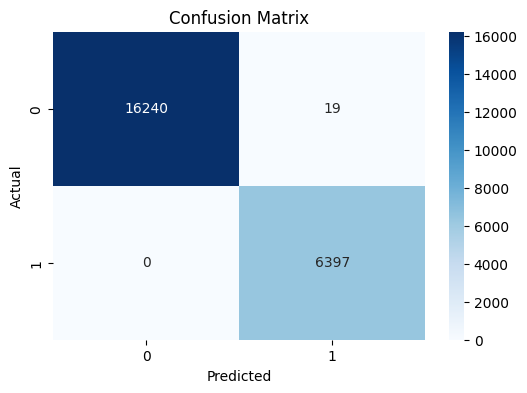

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16259
           1       1.00      1.00      1.00      6397

    accuracy                           1.00     22656
   macro avg       1.00      1.00      1.00     22656
weighted avg       1.00      1.00      1.00     22656

------------------------------------ KNeighborsClassifier(n_neighbors=10) ------------------------------------
Accuracy 0.9078
----------------------------------------------------------
Mean of Cross validation Score 0.9085
----------------------------------------------------------
AUC_ROC Score 0.9648
----------------------------------------------------------
Confusion Matrix


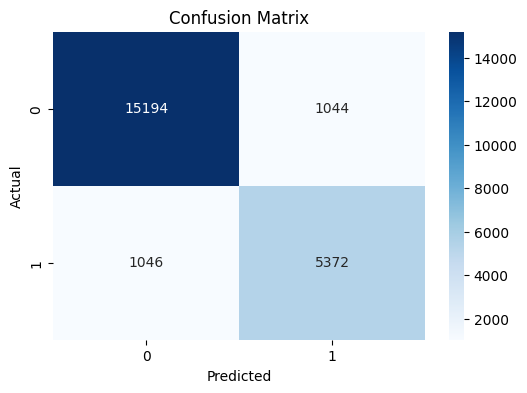

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     16238
           1       0.84      0.84      0.84      6418

    accuracy                           0.91     22656
   macro avg       0.89      0.89      0.89     22656
weighted avg       0.91      0.91      0.91     22656

------------------------------------ LogisticRegression() ------------------------------------
Accuracy 0.7466
----------------------------------------------------------
Mean of Cross validation Score 0.7512
----------------------------------------------------------
AUC_ROC Score 0.7571
----------------------------------------------------------
Confusion Matrix


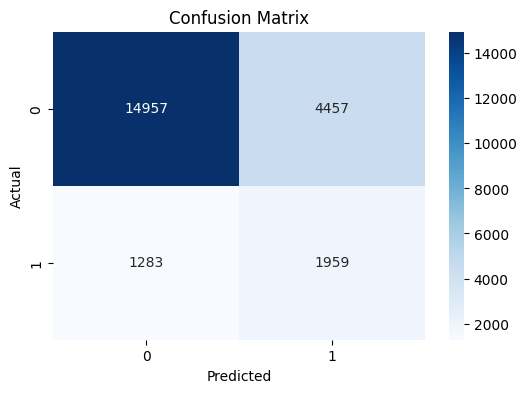

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.77      0.84     19414
           1       0.31      0.60      0.41      3242

    accuracy                           0.75     22656
   macro avg       0.61      0.69      0.62     22656
weighted avg       0.83      0.75      0.78     22656

------------------------------------ DecisionTreeClassifier() ------------------------------------
Accuracy 0.9995
----------------------------------------------------------
Mean of Cross validation Score 0.9998
----------------------------------------------------------
AUC_ROC Score 0.9994
----------------------------------------------------------
Confusion Matrix


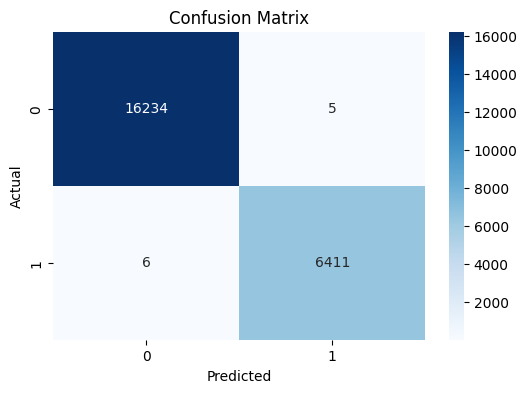

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16239
           1       1.00      1.00      1.00      6417

    accuracy                           1.00     22656
   macro avg       1.00      1.00      1.00     22656
weighted avg       1.00      1.00      1.00     22656

------------------------------------ RandomForestClassifier() ------------------------------------
Accuracy 0.9999
----------------------------------------------------------
Mean of Cross validation Score 0.9999
----------------------------------------------------------
AUC_ROC Score 1.0
----------------------------------------------------------
Confusion Matrix


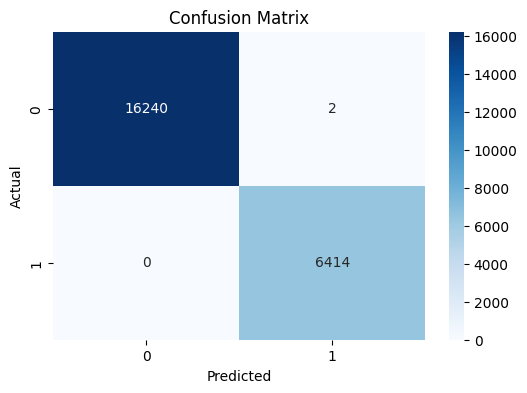

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16242
           1       1.00      1.00      1.00      6414

    accuracy                           1.00     22656
   macro avg       1.00      1.00      1.00     22656
weighted avg       1.00      1.00      1.00     22656

------------------------------------ XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None

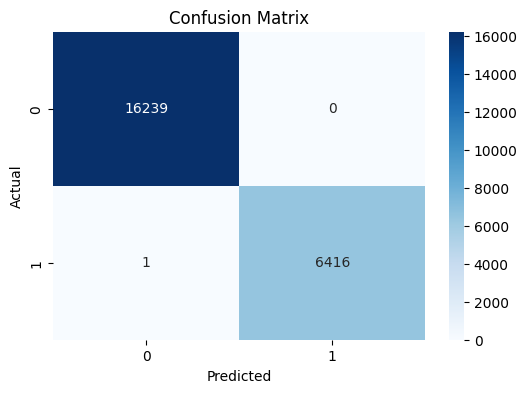

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16239
           1       1.00      1.00      1.00      6417

    accuracy                           1.00     22656
   macro avg       1.00      1.00      1.00     22656
weighted avg       1.00      1.00      1.00     22656

------------------------------------ BernoulliNB() ------------------------------------
Accuracy 0.9012
----------------------------------------------------------
Mean of Cross validation Score 0.9023
----------------------------------------------------------
AUC_ROC Score 0.9672
----------------------------------------------------------
Confusion Matrix


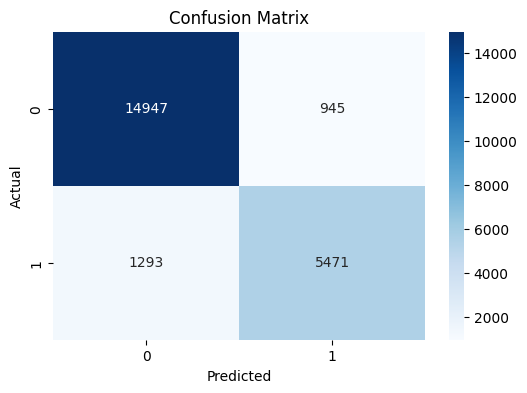

----------------------------------------------------------
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     15892
           1       0.85      0.81      0.83      6764

    accuracy                           0.90     22656
   macro avg       0.89      0.87      0.88     22656
weighted avg       0.90      0.90      0.90     22656



In [39]:
createmodel(X_train,y_train,X_test,y_test)